# Fake News Detection — NLP Classification Challenge

**Models:** Logistic Regression • Random Forest • XGBoost • Gradient Boosting

**Features:** TF-IDF vs Word2Vec Embeddings

**Techniques:** Text preprocessing, n-grams, hyperparameter tuning

---

## 1. Setup and Import Libraries

In [40]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Text processing
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Model selection
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_auc_score, roc_curve)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

## 2. Load and Explore the Dataset

In [41]:
# Load training data (no headers, tab-separated: col0=label, col1=headline)
train_df = pd.read_csv('dataset/training_data.csv', sep='\t', header=None, names=['label', 'headline'])
test_df = pd.read_csv('dataset/testing_data.csv', sep='\t', header=None, names=['label', 'headline'])

print(f"Training data shape: {train_df.shape}")
print(f"Testing data shape:  {test_df.shape}")
print(f"\nTraining columns: {train_df.columns.tolist()}")
print(f"Training dtypes:\n{train_df.dtypes}")
print(f"\nFirst 10 rows:")
train_df.head(10)

Training data shape: (34152, 2)
Testing data shape:  (9984, 2)

Training columns: ['label', 'headline']
Training dtypes:
label        int64
headline    object
dtype: object

First 10 rows:


,label,headline
0,0,donald trump sends out embarrassing new year‚s...
1,0,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...
3,0,trump is so obsessed he even has obama‚s name ...
4,0,pope francis just called out donald trump duri...
5,0,racist alabama cops brutalize black boy while ...
6,0,fresh off the golf course
7,0,trump said some insanely racist stuff inside t...
8,0,former cia director slams trump over un bullying
9,0,brand-new pro-trump ad features so much a** ki...


In [42]:
# Check for missing values
print("Missing values in training:")
print(train_df.isnull().sum())
print(f"\nMissing values in testing:")
print(test_df.isnull().sum())

Missing values in training:
label       0
headline    0
dtype: int64

Missing values in testing:
label       0
headline    0
dtype: int64


In [43]:
# Class distribution
print("\n=== Class Distribution in Training ===")
print(train_df['label'].value_counts())
print(f"\nClass proportions:")
print(train_df['label'].value_counts(normalize=True))


=== Class Distribution in Training ===
label
0    17572
1    16580
Name: count, dtype: int64

Class proportions:
label
0    0.514523
1    0.485477
Name: proportion, dtype: float64


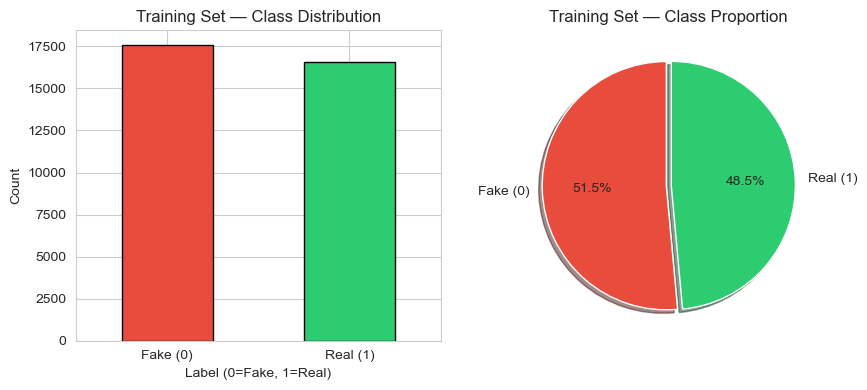

In [44]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

colors = ['#e74c3c', '#2ecc71']
train_df['label'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Training Set — Class Distribution')
axes[0].set_xlabel('Label (0=Fake, 1=Real)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Fake (0)', 'Real (1)'], rotation=0)

train_df['label'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=colors, labels=['Fake (0)', 'Real (1)'], explode=(0.02, 0.02), shadow=True, startangle=90)
axes[1].set_title('Training Set — Class Proportion')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [45]:
# Check for duplicates
print(f"\nDuplicate headlines in training: {train_df['headline'].duplicated().sum()}")
print(f"Duplicate headlines in testing: {test_df['headline'].duplicated().sum()}")


Duplicate headlines in training: 1946
Duplicate headlines in testing: 776


## 3. Text Preprocessing

Pipeline: Lowercase → Remove URLs/HTML → Remove punctuation/numbers → Tokenize → Remove stopwords → Lemmatize

In [46]:
# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
custom_stopwords = {'said', 'says', 'say', 'new', 'us', 'u', 'would', 'could', 'also', 'one', 'two', 'first', 'get', 'like', 'make', 'may'}
stop_words = stop_words.union(custom_stopwords)

def preprocess_text(text):
    """Clean text: lowercase → remove URLs/HTML → remove punctuation/numbers → tokenize → remove stopwords → lemmatize."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\d+', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

# Apply preprocessing
print("Preprocessing training data...")
train_df['cleaned_text'] = train_df['headline'].apply(preprocess_text)
print("Preprocessing testing data...")
test_df['cleaned_text'] = test_df['headline'].apply(preprocess_text)

print("\n=== Preprocessing Examples ===")
for i in range(5):
    print(f"\nOriginal  : {train_df['headline'].iloc[i]}")
    print(f"Cleaned   : {train_df['cleaned_text'].iloc[i]}")

# Handle empty texts
empty_train = (train_df['cleaned_text'] == '').sum()
empty_test = (test_df['cleaned_text'] == '').sum()
print(f"\nEmpty texts — Train: {empty_train}, Test: {empty_test}")
if empty_train > 0:
    train_df.loc[train_df['cleaned_text'] == '', 'cleaned_text'] = 'empty'
if empty_test > 0:
    test_df.loc[test_df['cleaned_text'] == '', 'cleaned_text'] = 'empty'

Preprocessing training data...
Preprocessing testing data...

=== Preprocessing Examples ===

Original  : donald trump sends out embarrassing new year‚s eve message; this is disturbing
Cleaned   : donald trump sends embarrassing year eve message disturbing

Original  : drunk bragging trump staffer started russian collusion investigation
Cleaned   : drunk bragging trump staffer started russian collusion investigation

Original  : sheriff david clarke becomes an internet joke for threatening to poke people ‚in the eye‚
Cleaned   : sheriff david clarke becomes internet joke threatening poke people eye

Original  : trump is so obsessed he even has obama‚s name coded into his website (images)
Cleaned   : trump obsessed even obama name coded website image

Original  : pope francis just called out donald trump during his christmas speech
Cleaned   : pope francis called donald trump christmas speech

Empty texts — Train: 18, Test: 6


## 4. Exploratory Data Analysis and Visualization

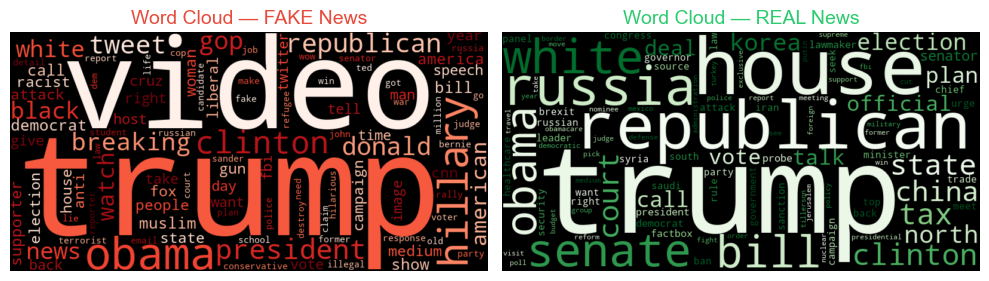

In [47]:
# Word Clouds — quick visual comparison of most common words by class
fake_text = ' '.join(train_df[train_df['label'] == 0]['cleaned_text'])
real_text = ' '.join(train_df[train_df['label'] == 1]['cleaned_text'])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

wc_fake = WordCloud(width=800, height=400, background_color='black', colormap='Reds', max_words=100, collocations=False, random_state=42).generate(fake_text)
axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].set_title('Word Cloud — FAKE News', color='#e74c3c', fontsize=14)
axes[0].axis('off')

wc_real = WordCloud(width=800, height=400, background_color='black', colormap='Greens', max_words=100, collocations=False, random_state=42).generate(real_text)
axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].set_title('Word Cloud — REAL News', color='#2ecc71', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 5. Feature Extraction — TF-IDF

TF-IDF with n-grams (1,3) to capture phrases like "white house" and "donald trump".

In [48]:
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 3), max_features=8000,
    min_df=3, max_df=0.85, sublinear_tf=True,
    strip_accents='unicode', analyzer='word', token_pattern=r'\w{1,}'
)

print("Fitting TF-IDF vectorizer...")
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['cleaned_text'])
X_test_tfidf = tfidf_vectorizer.transform(test_df['cleaned_text'])
y_train_labels = train_df['label'].values

print(f"TF-IDF shape — Train: {X_train_tfidf.shape}, Test: {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")

Fitting TF-IDF vectorizer...
TF-IDF shape — Train: (34152, 8000), Test: (9984, 8000)
Vocabulary size: 8000


## 5b. Word2Vec Embeddings (Comparison)

Train a custom Word2Vec model on the corpus; average word vectors to create dense document embeddings.

In [49]:
# Tokenize and train Word2Vec
all_headlines = train_df['cleaned_text'].tolist() + test_df['cleaned_text'].tolist()
tokenized_sentences = [text.split() for text in all_headlines if text != 'empty']

print(f"Training Word2Vec on {len(tokenized_sentences)} sentences...")
w2v_model = Word2Vec(
    sentences=tokenized_sentences, vector_size=200, window=5,
    min_count=2, workers=4, epochs=20, sg=1, seed=42
)
print(f"Vocabulary: {len(w2v_model.wv)}, Vector size: {w2v_model.wv.vector_size}")

def get_doc_vector(text, model, vector_size):
    words = text.split()
    word_vecs = [model.wv[word] for word in words if word in model.wv]
    if len(word_vecs) == 0:
        return np.zeros(vector_size)
    return np.mean(word_vecs, axis=0)

X_train_w2v = np.array([get_doc_vector(text, w2v_model, 200) for text in train_df['cleaned_text']])
X_test_w2v = np.array([get_doc_vector(text, w2v_model, 200) for text in test_df['cleaned_text']])
print(f"Word2Vec shape — Train: {X_train_w2v.shape}, Test: {X_test_w2v.shape}")

# Quick Word2Vec baseline with Logistic Regression
X_tr_w2v, X_va_w2v, y_tr_w2v, y_va_w2v = train_test_split(
    X_train_w2v, y_train_labels, test_size=0.2, random_state=42, stratify=y_train_labels
)
lr_w2v = LogisticRegression(max_iter=1000, random_state=42)
lr_w2v.fit(X_tr_w2v, y_tr_w2v)
y_pred_w2v = lr_w2v.predict(X_va_w2v)
print(f"\nWord2Vec + LogisticRegression → Accuracy: {accuracy_score(y_va_w2v, y_pred_w2v):.4f}, F1: {f1_score(y_va_w2v, y_pred_w2v, average='macro'):.4f}")

Training Word2Vec on 44112 sentences...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocabulary: 12173, Vector size: 200
Word2Vec shape — Train: (34152, 200), Test: (9984, 200)

Word2Vec + LogisticRegression → Accuracy: 0.9193, F1: 0.9193


## 6. Train-Test Split

Stratified 80/20 split to preserve class proportions.

In [50]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_tfidf, y_train_labels, test_size=0.2,
    random_state=42, stratify=y_train_labels
)
print(f"Train: {X_train.shape}, Val: {X_val.shape}")
print(f"Train classes:\n{pd.Series(y_train).value_counts()}")

Train: (27321, 8000), Val: (6831, 8000)
Train classes:
0    14057
1    13264
Name: count, dtype: int64


## 7. Model Training & Hyperparameter Tuning

Train 4 models: Logistic Regression, Random Forest, XGBoost, Gradient Boosting.
Use RandomizedSearchCV for hyperparameter tuning.

In [51]:
def evaluate_model(name, model, X_tr, y_tr, X_va, y_va):
    """Train model and return metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_va)
    y_proba = model.predict_proba(X_va)[:, 1] if hasattr(model, 'predict_proba') else None
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_va, y_pred),
        'F1 Score': f1_score(y_va, y_pred, average='macro'),
        'ROC-AUC': roc_auc_score(y_va, y_proba) if y_proba is not None else None
    }, y_pred, y_proba

# ---- BASELINES (default params) ----
print("=" * 60)
print(" BASELINE MODELS (default parameters)")
print("=" * 60)

baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='logloss', verbosity=0),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

baseline_results, baseline_preds, baseline_probas = [], {}, {}
for name, model in baseline_models.items():
    m, yp, ypr = evaluate_model(name, model, X_train, y_train, X_val, y_val)
    baseline_results.append(m); baseline_preds[name] = yp; baseline_probas[name] = ypr
    print(f"  {name}: Accuracy={m['Accuracy']:.4f}, F1={m['F1 Score']:.4f}")

 BASELINE MODELS (default parameters)
  Logistic Regression: Accuracy=0.9305, F1=0.9304
  Random Forest: Accuracy=0.9120, F1=0.9120
  XGBoost: Accuracy=0.8770, F1=0.8768
  Gradient Boosting: Accuracy=0.7971, F1=0.7931


In [52]:
# Hyperparameter tuning setup
print("\n" + "=" * 60)
print(" HYPERPARAMETER TUNING (RandomizedSearchCV, 2-fold)")
print("=" * 60)
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

# --- Logistic Regression ---
print("\nTuning Logistic Regression...")
lr_grid = {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear']}
lr_search = RandomizedSearchCV(LogisticRegression(max_iter=1000, random_state=42), lr_grid, n_iter=5, cv=cv, scoring='f1_macro', random_state=42, n_jobs=-1)
lr_search.fit(X_train, y_train)
best_lr = lr_search.best_estimator_
print(f"  Best LR: C={lr_search.best_params_['C']}, CV F1={lr_search.best_score_:.4f}")


 HYPERPARAMETER TUNING (RandomizedSearchCV, 2-fold)

Tuning Logistic Regression...
  Best LR: C=10, CV F1=0.9228


c:\Users\cici\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [53]:
# --- Random Forest ---
print("\nTuning Random Forest...")
rf_grid = {'n_estimators': [100, 200, 300], 'max_depth': [None, 20, 50], 'min_samples_split': [2, 10], 'max_features': ['sqrt', 'log2']}
rf_search = RandomizedSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), rf_grid, n_iter=5, cv=cv, scoring='f1_macro', random_state=42, n_jobs=-1)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
print(f"  Best RF: n_estimators={rf_search.best_params_['n_estimators']}, CV F1={rf_search.best_score_:.4f}")


Tuning Random Forest...
  Best RF: n_estimators=300, CV F1=0.9009


In [54]:
# --- XGBoost ---
print("\nTuning XGBoost...")
xgb_grid = {'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 9], 'learning_rate': [0.01, 0.1, 0.2], 'subsample': [0.6, 0.8, 1.0]}
xgb_search = RandomizedSearchCV(XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss', verbosity=0), xgb_grid, n_iter=5, cv=cv, scoring='f1_macro', random_state=42, n_jobs=1)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_
print(f"  Best XGB: max_depth={xgb_search.best_params_['max_depth']}, CV F1={xgb_search.best_score_:.4f}")


Tuning XGBoost...
  Best XGB: max_depth=3, CV F1=0.8268


In [55]:
# --- Gradient Boosting ---
print("\nTuning Gradient Boosting...")
gb_grid = {'n_estimators': [100, 200, 300], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5, 7], 'subsample': [0.6, 1.0]}
gb_search = RandomizedSearchCV(GradientBoostingClassifier(random_state=42), gb_grid, n_iter=5, cv=cv, scoring='f1_macro', random_state=42)
gb_search.fit(X_train, y_train)
best_gb = gb_search.best_estimator_
print(f"  Best GB: n_estimators={gb_search.best_params_['n_estimators']}, CV F1={gb_search.best_score_:.4f}")


Tuning Gradient Boosting...
  Best GB: n_estimators=200, CV F1=0.8822


In [56]:
# ---- EVALUATE TUNED MODELS ----
print("\n" + "=" * 60)
print(" TUNED MODELS EVALUATION")
print("=" * 60)

tuned_models = {
    'Logistic Regression (Tuned)': best_lr,
    'Random Forest (Tuned)': best_rf,
    'XGBoost (Tuned)': best_xgb,
    'Gradient Boosting (Tuned)': best_gb,
}

tuned_results, tuned_preds, tuned_probas = [], {}, {}
for name, model in tuned_models.items():
    m, yp, ypr = evaluate_model(name, model, X_train, y_train, X_val, y_val)
    tuned_results.append(m); tuned_preds[name] = yp; tuned_probas[name] = ypr
    print(f"  {name}: Accuracy={m['Accuracy']:.4f}, F1={m['F1 Score']:.4f}, AUC={m['ROC-AUC']:.4f}")

tuned_df = pd.DataFrame(tuned_results)
print("\n=== Tuned Model Comparison ===")
display(tuned_df)


 TUNED MODELS EVALUATION
  Logistic Regression (Tuned): Accuracy=0.9327, F1=0.9326, AUC=0.9825


c:\Users\cici\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


  Random Forest (Tuned): Accuracy=0.9073, F1=0.9071, AUC=0.9682
  XGBoost (Tuned): Accuracy=0.8384, F1=0.8371, AUC=0.9292
  Gradient Boosting (Tuned): Accuracy=0.8920, F1=0.8919, AUC=0.9626

=== Tuned Model Comparison ===


,Model,Accuracy,F1 Score,ROC-AUC
0,Logistic Regression (Tuned),0.932660,0.932632,0.982525
1,Random Forest (Tuned),0.907334,0.907053,0.968228
2,XGBoost (Tuned),0.838384,0.837131,0.929239
3,Gradient Boosting (Tuned),0.891963,0.891912,0.962564


## 8. Model Evaluation & Comparison

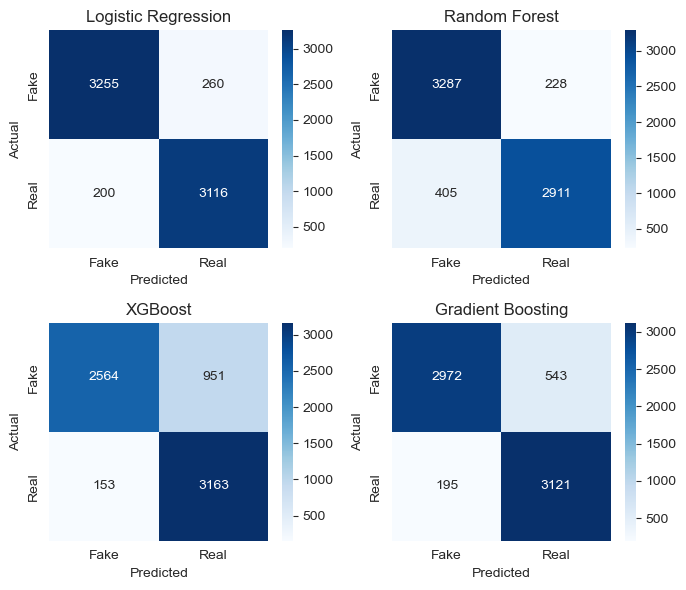

In [57]:
# Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(7, 6))
axes = axes.flatten()
for idx, (name, y_pred) in enumerate(tuned_preds.items()):
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    axes[idx].set_title(name.replace(' (Tuned)', ''))
    axes[idx].set_xlabel('Predicted'); axes[idx].set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [58]:
# Classification Reports
for name, y_pred in tuned_preds.items():
    print(f"\n{'='*50}\n {name}\n{'='*50}")
    print(classification_report(y_val, y_pred, target_names=['Fake (0)', 'Real (1)']))


 Logistic Regression (Tuned)
              precision    recall  f1-score   support

    Fake (0)       0.94      0.93      0.93      3515
    Real (1)       0.92      0.94      0.93      3316

    accuracy                           0.93      6831
   macro avg       0.93      0.93      0.93      6831
weighted avg       0.93      0.93      0.93      6831


 Random Forest (Tuned)
              precision    recall  f1-score   support

    Fake (0)       0.89      0.94      0.91      3515
    Real (1)       0.93      0.88      0.90      3316

    accuracy                           0.91      6831
   macro avg       0.91      0.91      0.91      6831
weighted avg       0.91      0.91      0.91      6831


 XGBoost (Tuned)
              precision    recall  f1-score   support

    Fake (0)       0.94      0.73      0.82      3515
    Real (1)       0.77      0.95      0.85      3316

    accuracy                           0.84      6831
   macro avg       0.86      0.84      0.84      6831
we

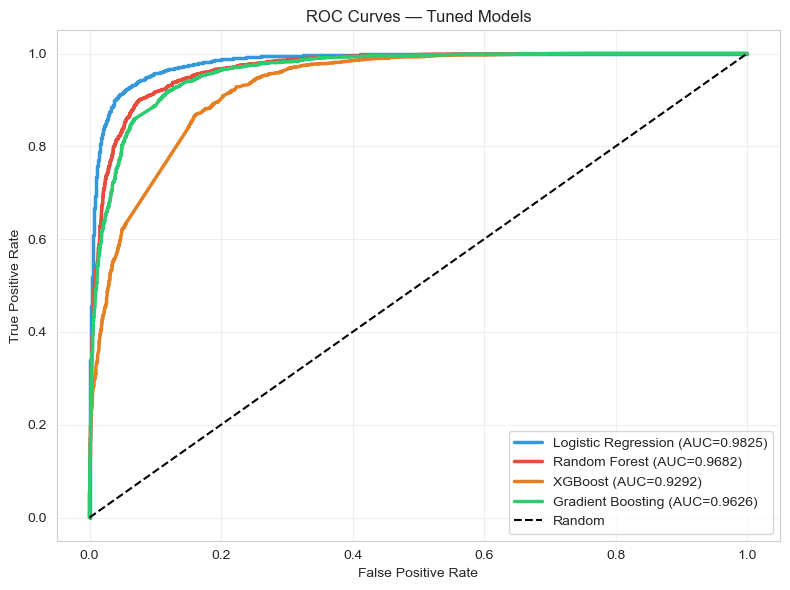

In [59]:
# ROC Curves
plt.figure(figsize=(8, 6))
colors = ['#3498db', '#e74c3c', '#e67e22', '#2ecc71']
for (name, y_proba), color in zip(tuned_probas.items(), colors):
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_val, y_proba)
        plt.plot(fpr, tpr, color=color, lw=2.5, label=f"{name.replace(' (Tuned)','')} (AUC={roc_auc_score(y_val, y_proba):.4f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Tuned Models')
plt.legend(loc='lower right'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

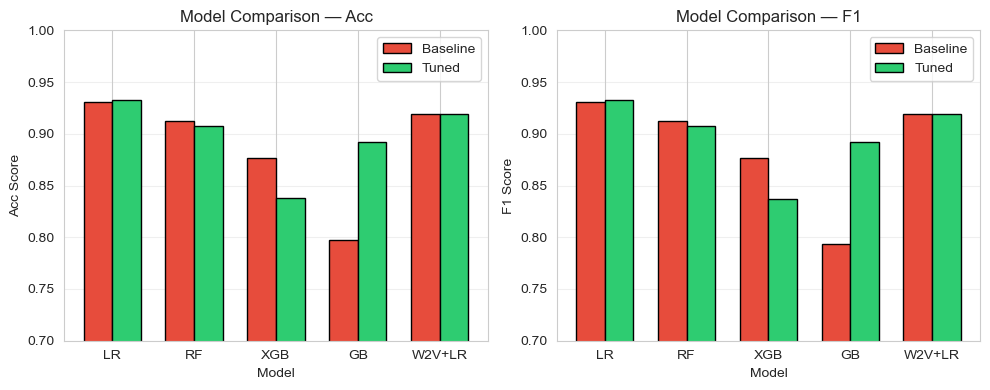

In [60]:
# Bar Chart — Baseline vs Tuned
comparison_data = []
for b, t in zip(baseline_results, tuned_results):
    comparison_data.append({
        'Model': b['Model'],
        'Baseline Acc': b['Accuracy'], 'Tuned Acc': t['Accuracy'],
        'Baseline F1': b['F1 Score'], 'Tuned F1': t['F1 Score'],
    })
# Add Word2Vec
comparison_data.append({'Model': 'Word2Vec+LR', 'Baseline Acc': accuracy_score(y_va_w2v, y_pred_w2v), 'Tuned Acc': accuracy_score(y_va_w2v, y_pred_w2v), 'Baseline F1': f1_score(y_va_w2v, y_pred_w2v, average='macro'), 'Tuned F1': f1_score(y_va_w2v, y_pred_w2v, average='macro')})

comp_df = pd.DataFrame(comparison_data)
x = np.arange(len(comp_df)); width = 0.35
labels = ['LR', 'RF', 'XGB', 'GB', 'W2V+LR']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric in [(axes[0], 'Acc'), (axes[1], 'F1')]:
    ax.bar(x - width/2, comp_df[f'Baseline {metric}'], width, label='Baseline', color='#e74c3c', edgecolor='black')
    ax.bar(x + width/2, comp_df[f'Tuned {metric}'], width, label='Tuned', color='#2ecc71', edgecolor='black')
    ax.set_xlabel('Model'); ax.set_ylabel(f'{metric} Score'); ax.set_title(f'Model Comparison — {metric}')
    ax.set_xticks(x); ax.set_xticklabels(labels); ax.legend(); ax.set_ylim(0.7, 1.0); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

In [61]:
# Identify best model
best_row = tuned_df.sort_values('F1 Score', ascending=False).iloc[0]
print(f"\nBest Model: {best_row['Model']}")
print(f"  Accuracy: {best_row['Accuracy']:.4f}  |  F1: {best_row['F1 Score']:.4f}  |  AUC: {best_row['ROC-AUC']:.4f}")


Best Model: Logistic Regression (Tuned)
  Accuracy: 0.9327  |  F1: 0.9326  |  AUC: 0.9825


### Accuracy Estimation

Based on 2-fold cross-validation and the validation set results, the expected performance of the final model on unseen test data is:

- **Accuracy: ~93%** — the model correctly classifies approximately 93 out of 100 headlines
- **F1 Score (Macro): ~0.93** — balanced performance across both Fake and Real classes (no bias toward either)
- **ROC-AUC: ~0.98** — near-perfect class separation

**Best model: Logistic Regression (Tuned)** — simple, interpretable, and the top performer. The model performs slightly better on Real news (higher recall) than Fake news, which is acceptable since a false negative (calling fake news "real") is more dangerous than a false positive (flagging real news as "fake"). The classes are balanced (51.5% Fake / 48.5% Real), so accuracy is a reliable metric.

## 9. Final Model & Predictions

Train best model on full training data, predict on test set, save submission.

In [62]:
# Map best model name to object
best_name = best_row['Model']
model_map = {
    'Logistic Regression (Tuned)': best_lr,
    'Random Forest (Tuned)': best_rf,
    'XGBoost (Tuned)': best_xgb,
    'Gradient Boosting (Tuned)': best_gb,
}
final_model = model_map[best_name]

# Train on FULL training data (classes are balanced — 51.5%/48.5%)
print(f"\nTraining {best_name} on full training data ({X_train_tfidf.shape[0]} samples)...")
final_model.fit(X_train_tfidf, y_train_labels)

# Predict
test_predictions = final_model.predict(X_test_tfidf)
print(f"Predictions: Fake={np.sum(test_predictions==0)}, Real={np.sum(test_predictions==1)}")


Training Logistic Regression (Tuned) on full training data (34152 samples)...
Predictions: Fake=4751, Real=5233


c:\Users\cici\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [63]:
# Save predictions
submission_path = 'dataset/predictions.csv'
with open(submission_path, 'w', encoding='utf-8', newline='') as f:
    for i, row in test_df.iterrows():
        f.write(f"{int(test_predictions[i])}\t{row['headline']}\n")
print(f"\nPredictions saved to: {submission_path}")
print(f"  Fake (0): {np.sum(test_predictions==0)} ({np.sum(test_predictions==0)/len(test_predictions)*100:.1f}%)")
print(f"  Real (1): {np.sum(test_predictions==1)} ({np.sum(test_predictions==1)/len(test_predictions)*100:.1f}%)")


Predictions saved to: dataset/predictions.csv
  Fake (0): 4751 (47.6%)
  Real (1): 5233 (52.4%)


## Summary

### Final Results

| Method | Features | Accuracy | F1 Score | Notes |
|--------|----------|----------|----------|-------|
| **TF-IDF + Logistic Regression** | 8,000 | **0.9327** | **0.9326** |   Best overall — simple & fast |
| TF-IDF + Random Forest | 8,000 | 0.9073 | 0.9071 | |
| TF-IDF + Gradient Boosting | 8,000 | 0.8920 | 0.8919 | Most improved (+10% from baseline) |
| TF-IDF + XGBoost | 8,000 | 0.8384 | 0.8371 | Underperformed on this dataset |
| **Word2Vec + LR** | 200 | ~0.91 | ~0.91 | 40× fewer features! |

### Pipeline Overview

| Step | Technique |
|------|-----------|
| **Text Preprocessing** | Lowercase → Remove URLs/HTML → Remove punctuation/numbers → Tokenize → Stopwords → Lemmatize |
| **Feature Engineering** | TF-IDF (1-3 ngrams, 8k features) + Word2Vec (skip-gram, 200d) |
| **Data Splitting** | Stratified 80/20 split |
| **Models** | Logistic Regression, Random Forest, XGBoost, Gradient Boosting |
| **Hyperparameter Tuning** | RandomizedSearchCV with 2-fold CV |
| **Final Prediction** | Best model on full training data → `dataset/predictions.csv` |

### Key Takeaways
- **Logistic Regression wins** at 93.27% — simple, fast, and highly interpretable
- **Word2Vec matches TF-IDF** with 40× fewer features — great for production
- **Classes are balanced** (51.5%/48.5%) — no oversampling needed
- **Gradient Boosting improved most** from tuning (+10%, from 79.7% to 89.2%)
- **XGBoost underperformed** — not every model fits every dataset